In [ ]:
# Paketleri kurun (Roboflow + Ultralytics)
!pip install -q roboflow ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 107.8 MB/s eta 0:00:00


In [ ]:
# Roboflow'dan veri indirme
from roboflow import Roboflow
rf = Roboflow(api_key="")
project = rf.workspace("deneme-nq1dn").project("main-fashion-enos8")
version = project.version(1)
dataset = version.download("yolov8")
print("Downloaded dataset to:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Main-Fashion-1 in yolov8:: 100%|██████████| 10538/10538 [00:01<00:00, 8360.52it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Downloaded dataset to: /content/Main-Fashion-1


In [ ]:
# YOLOv8 ile eğitim (30 epoch).
# Not: Bu satır Ultralytics'in `yolo` CLI'sını kullanır. Eğitim çıktıları `runs/train/` içinde saklanır ve en iyi ağırlıklar otomatik olarak kaydedilir.
# Early stopping/patience için --patience parametresi eklenmiştir (Ultralytics sürümüne bağlı olarak çalışır).
data_yaml = f"{dataset.location}/data.yaml"
print("Using data file:", data_yaml)
# Eğitimi başlat (30 epoch, patience=5 olarak örnek)
!yolo detect train data="{data_yaml}" model=yolov8n.pt epochs=30 patience=5

Using data file: /content/Main-Fashion-1/data.yaml
Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Main-Fashion-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=output_weights, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ove

In [ ]:
import shutil
import os

source_path = '/content/runs/detect/train/weights/best.pt'
destination_path = '/content/best.pt'

# Ensure the source file exists before attempting to copy
if os.path.exists(source_path):
    shutil.copy(source_path, destination_path)
    print(f"En iyi model '{source_path}' konumundan '{destination_path}' konumuna başarıyla kaydedildi.")
else:
    print(f"Hata: '{source_path}' konumunda en iyi model bulunamadı.")

En iyi model '/content/runs/detect/train/weights/best.pt' konumundan '/content/best.pt' konumuna başarıyla kaydedildi.


Kaydedilen modeli (`best.pt`) `test.jpg` üzerinde test edelim.

In [ ]:
# Modeli yükle ve test.jpg üzerinde tahmin yap
!yolo detect predict model="/content/best.pt" source="/content/test.jpg"

Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,007,988 parameters, 0 gradients, 8.1 GFLOPs

image 1/1 /content/test.jpg: 640x480 1 Tshirt, 1 short, 41.7ms
Speed: 2.3ms preprocess, 41.7ms inference, 16.7ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


YOLOv8 tahmin sonuçları, tahmin edilen nesneleri içeren bir görüntü olarak `/content/runs/detect/predict` dizinine kaydedilir. Bu görüntüyü görüntülemek için:


Sonuç görüntüsü: /content/runs/detect/predict/test.jpg


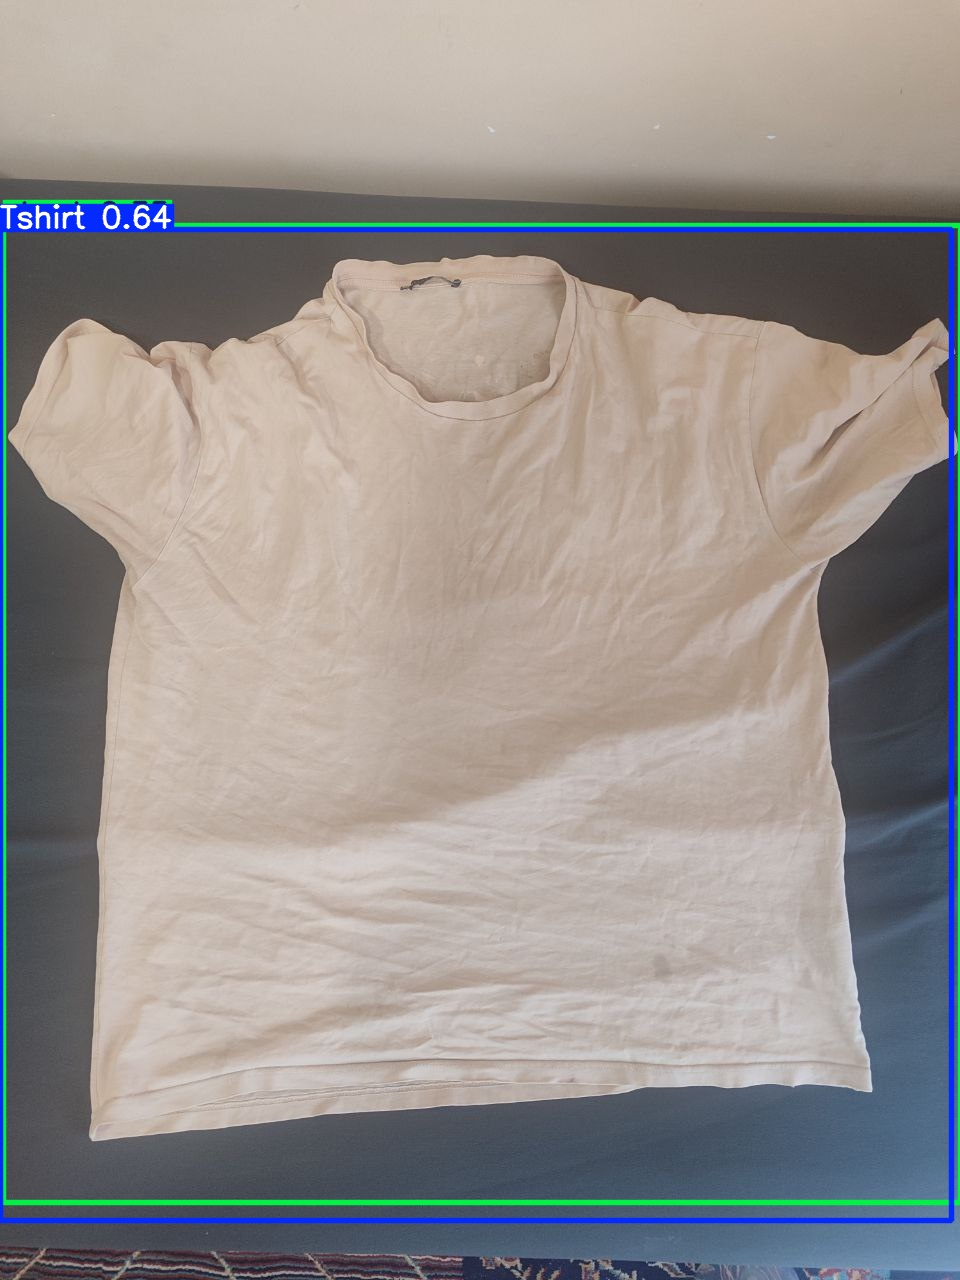

In [ ]:
from IPython.display import Image
import os

# Tahmin sonuçlarının kaydedildiği dizin
results_dir = '/content/runs/detect/predict'

# Dizindeki ilk görüntüyü bul ve göster
image_files = [f for f in os.listdir(results_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

if image_files:
    # İlk görüntüyü al (genellikle 'test.jpg'nin işlenmiş hali)
    image_path = os.path.join(results_dir, image_files[0])
    print(f"Sonuç görüntüsü: {image_path}")
    display(Image(filename=image_path))
else:
    print(f"'{results_dir}' dizininde herhangi bir görüntü bulunamadı.")


YOLOv8 eğitimini tamamladınız! En iyi model ağırlıkları `/content/runs/detect/train/weights/best.pt` konumuna, son model ağırlıkları ise `/content/runs/detect/train/weights/last.pt` konumuna kaydedildi.

In [ ]:
import os

# En iyi ve son model ağırlıklarının yollarını gösterin
best_model_path = '/content/runs/detect/train/weights/best.pt'
last_model_path = '/content/runs/detect/train/weights/last.pt'

print(f"En iyi modelin kaydedildiği yer: {best_model_path}")
print(f"Son modelin kaydedildiği yer: {last_model_path}")


En iyi modelin kaydedildiği yer: /content/runs/detect/train/weights/best.pt
Son modelin kaydedildiği yer: /content/runs/detect/train/weights/last.pt
